## Visualization of the TTF artifacts and modifications

In [1]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '2'

from typing import Optional, Union, Sequence
from tqdm import tqdm
import numpy as np
import torch
from nflows.transforms import Transform
import normflows as nf
import matplotlib.pyplot as plt
import openturns as ot

from tailnflows.targets.synth_targets import Target, GaussianCopula
from tailnflows.models.extreme_transformations import TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform, SoftLogMarginalTransform

torch.cuda.set_device(3)
device = torch.device(f"cuda:{3}" if torch.cuda.is_available() else "cpu")

torch.set_num_threads(4)

print("Using device: ", device)
print("Current CUDA device:", torch.cuda.current_device())
print("All CUDA devices:", torch.cuda.device_count())

DEFAULT_DTYPE = torch.float32

Using device:  cuda:3
Current CUDA device: 3
All CUDA devices: 4


### Prepare target distribution, base distribution and visualization parameters that all models share:

In [2]:
# Mixed-tailed Gaussian Copula target
df = 2.0
target = GaussianCopula(
    num_light = 1,
    num_heavy = 1,
    df = df,
    corr_matrix = ot.CorrelationMatrix(2, (1.0, 0.75, 0.75, 1.0))
)
target = target.to(device)

# Set base distribuiton
q0 = nf.distributions.DiagGaussian(2, trainable=False)
q0 = q0.to(device)

# Architectural parameters for flow models
num_layers = 4
num_blocks = 3
num_hidden_channels = 64

# 
hd_only = True

# Parameters for plots
x_low, x_high = -5.5, 5.5
y_low, y_high = -5.5, 5.5

range_hist2d = ((x_low,x_high), (y_low, y_high))
extent_imshow = (x_low, x_high, y_low, y_high)

# Prepare grid
bins = 250
grid_size = 250
grid = torch.meshgrid(torch.linspace(x_low, x_high, grid_size), torch.linspace(y_low, y_high, grid_size), indexing='xy')
grid = torch.stack([grid[0].flatten(), grid[1].flatten()], dim=1).to(device)
print("grid.shape: ", grid.shape)

grid.shape:  torch.Size([62500, 2])


WRN - As nu <= 2, the covariance of the distribution will not be defined


### Visualize target distribution:

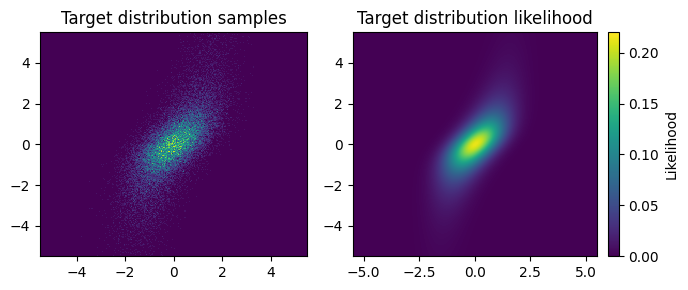

In [3]:
# Sample from target
x_np = target.sample(32000).detach().cpu().numpy()

# Compute likelihood on grid
target_log_p = target.log_prob(grid)
target_likelihood = torch.exp(target_log_p).reshape(grid_size, grid_size)
target_likelihood = target_likelihood.detach().cpu().numpy()

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# switching to new colorbar for likelihoods to better see the tail
cmap = LinearSegmentedColormap.from_list("yellow_red_white", ["white", "red", "yellow"])
cmap = "viridis"
vmin = 0
vmax = 0.22

# Create plots
fig, axs = plt.subplots(1, 2, figsize=(7, 3))
axs[0].hist2d(x_np[:, 0], x_np[:, 1], bins=bins, range=range_hist2d, density=True, cmap=cmap)
axs[0].set_title('Target distribution samples')
axs[1].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap=cmap, vmin=0,vmax=0.22)
axs[1].set_title('Target distribution likelihood')
# add colorbar to right of axs[1]
cbar = fig.colorbar(axs[1].images[0], ax=axs[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Likelihood')
fig.tight_layout()
fig.show()

In [4]:
# quick estimate of entropy of target distribution, for lower bound on loss
entropy_estimate = -target.log_prob(target.sample(500000)).mean().detach().cpu().numpy()
print("Estimated entropy of target distribution: ", entropy_estimate)
print("Later we use it per dimension (WHY?) so we divide by 2: ", entropy_estimate/2.0)

Estimated entropy of target distribution:  2.966104103152278
Later we use it per dimension (WHY?) so we divide by 2:  1.483052051576139


In [5]:
# setting up the experiments -> following Pachebat setup

# TODO -> replace target with finitely many training samples
n_train = 10_000
X_train = target.sample(num_samples=n_train)

In [6]:
# ensure similar compute budget/number of params -> 50k? -> so better around 130k params...

# set up MLP with MLP backbone (4 layers, width 256, SiLU), to estimate number of params

import torch
from torch import nn

class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=256, num_layers=4):
        super().__init__()
        # input layer
        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        # intermediate
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())
        # output layer
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# count number of params
model = MLP(input_dim=2, output_dim=2)  # example input and output dimensions
num_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {num_params}")

Number of parameters: 132866


In [7]:
# dict to store all results
results = {}

results_dir = "results_synthetic_HDonly/"
import os
os.makedirs(results_dir, exist_ok=True)

In [8]:
from tailnflows.metrics import sliced_wp, wp_1d_mean_over_dims, extreme_quantile_rel_error_multiq_over_dims

def eval_results(model, target):
    """
    Quick evaluation of model performance against the target distribution.
    Flow matching models have get_average_nll and bin_count implemented, normalizing flows use their generic function.
    """
    # test whether model has method 'get_average_nll'
    if not hasattr(model, 'get_average_nll'):
        print("Model does not have method 'get_average_nll', using the generic one for norm flows...")
        # compute nll
        nll = get_average_nll(model, target, 64000)
    else:
        nll = model.get_average_nll(target, 64000)
    print(f"Average NLL (per dim!): {nll:.3f}")

    # Count samples in bin around 0 for each dimension
    if not hasattr(model, 'bin_count'):
        (avg_true_samps_in_bin_dim0, std_true_samps_in_bin_dim0), (avg_flow_samps_in_bin_dim0, std_flow_samps_in_bin_dim0) = bin_count(nf_model=model, target=target, dim=0)
        (avg_true_samps_in_bin_dim1, std_true_samps_in_bin_dim1), (avg_flow_samps_in_bin_dim1, std_flow_samps_in_bin_dim1) = bin_count(nf_model=model, target=target, dim=1)
    else:
        (avg_true_samps_in_bin_dim0, std_true_samps_in_bin_dim0), (avg_flow_samps_in_bin_dim0, std_flow_samps_in_bin_dim0) = model.bin_count(target=target, dim=0)
        (avg_true_samps_in_bin_dim1, std_true_samps_in_bin_dim1), (avg_flow_samps_in_bin_dim1, std_flow_samps_in_bin_dim1) = model.bin_count(target=target, dim=1)
    print(f"Average num true samps, num flow samps in bin (dim 0): {avg_true_samps_in_bin_dim0:.0f} ± {std_true_samps_in_bin_dim0:.0f} vs {avg_flow_samps_in_bin_dim0:.0f} ± {std_flow_samps_in_bin_dim0:.0f}")
    print(f"Average num true samps, num flow samps in bin (dim 1): {avg_true_samps_in_bin_dim1:.0f} ±{std_true_samps_in_bin_dim1:.0f} vs {avg_flow_samps_in_bin_dim1:.0f} ± {std_flow_samps_in_bin_dim1:.0f}")

    # test samples
    try:
        model_samples, _ = model.sample(16000) # normalizing flows
    except ValueError:
        model_samples = model.sample(16000)    # flow matching
    test_samples = target.sample(16000)

    # compute sliced Wasserstein distance
    swp = sliced_wp(model_samples, test_samples)
    print(f"Sliced Wasserstein distance: {swp:.3f}")

    light_tail_idx = torch.tensor([True, False]).to('cpu')
    heavy_tail_idx = torch.tensor([False, True]).to('cpu')

    # compute 1D Wasserstein distance mean over dimensions
    light_tail_avg_wp_1d = wp_1d_mean_over_dims(model_samples.to('cpu'), test_samples.to('cpu'), dims=light_tail_idx)
    heavy_tail_avg_wp_1d = wp_1d_mean_over_dims(model_samples.to('cpu'), test_samples.to('cpu'), dims=heavy_tail_idx)

    print(f"1D Wasserstein distance mean over light tail dims: {light_tail_avg_wp_1d:.3f}")
    print(f"1D Wasserstein distance mean over heavy tail dims: {heavy_tail_avg_wp_1d:.3f}")

    # compute extreme quantile relative error
    # extreme_qre = extreme_quantile_rel_error_multiq_over_dims(model_samples.to('cpu'), test_samples.to('cpu'), dims=light_tail_idx)
    # print(f"Extreme quantile relative error: {extreme_qre:.3f}")

    # return as dict
    return {
        "nll": nll,
        "sliced_wp": swp,
        "light_tail_avg_wp_1d": light_tail_avg_wp_1d,
        "heavy_tail_avg_wp_1d": heavy_tail_avg_wp_1d,
        "gt_samples_dim0": str(round(avg_true_samps_in_bin_dim0)) + " ± " + str(round(std_true_samps_in_bin_dim0)),
        "flow_samples_dim0": str(round(avg_flow_samps_in_bin_dim0)) + " ± " + str(round(std_flow_samps_in_bin_dim0)),
        "gt_samples_dim1": str(round(avg_true_samps_in_bin_dim1)) + " ± " + str(round(std_true_samps_in_bin_dim1)),
        "flow_samples_dim1": str(round(avg_flow_samps_in_bin_dim1)) + " ± " + str(round(std_flow_samps_in_bin_dim1)),
    }

### Fit NF models
We train discrete Neural Spline Flow (NSF) models here:

In [9]:
# Prepare flow layers for NSF models
def build_flows():
    flows = []
    for _ in range(num_layers):
        
        flows += [
            nf.flows.AutoregressiveRationalQuadraticSpline(
                num_input_channels=2,
                num_hidden_channels=num_hidden_channels,
                num_blocks=num_blocks,
                init_identity=True,
            ),

            nf.flows.ActNorm(2),

            nf.flows.LULinearPermute(2),
        ]
    return flows


# Training algorithm
def train(nf_model: nf.NormalizingFlow, target: Target, num_steps: int = 1000, batch_size: int = 1024, show_every: Optional[int] = None, lr: float = 1e-4, weight_decay: float = 1e-5,
          model_name: str = None):
    """ Train the model on target distribution.

    Args:
        nf_model (nf.NormalizingFlow): NF model to train.
        target (Union[Target, torch.tensor]): Target distribution to train the model on.
        num_steps (int, optional): Number of training steps. Defaults to 1000.
        batch_size (int, optional): Defaults to 2**9.
        show_every (int, optional): Period for visualizing intermediate results (only for 2dim). If None, no intermediate results are computed. Defaults to None.
        lr (float, optional): Learning rate for optimizer. Defaults to 1e-3.
        model_name (str, optional): Name of the model for saving intermediate results. Defaults to None.
        weight_decay (float, optional): Weight decay for optimizer. Defaults to 1e-5.
    """

    # Prepare loss history
    loss_hist = np.array([])

    # Get training samples for initial loss
    x = target.sample(batch_size).float().to(device)
    # Compute and log initial loss
    loss = nf_model.forward_kld(x)
    loss_hist = np.append(loss_hist, loss.to('cpu').item())

    # Training loop
    optimizer = torch.optim.AdamW(nf_model.parameters(), lr=lr, weight_decay=weight_decay)

    # Initialize the actnorm layers
    calibration_batch = target.sample(2048).to(dtype=DEFAULT_DTYPE, device=device)
    nf_model.train()
    with torch.no_grad():
        for flow in nf_model.flows:
            _ = nf_model.forward_kld(calibration_batch)
    print("ActNorm layers calibrated..")

    pbar = tqdm(range(num_steps), desc="Training the flow")
    for step in pbar:
        optimizer.zero_grad()
        
        # Get training batch
        x = target.sample(batch_size).to(dtype=DEFAULT_DTYPE, device=device)
        
        # Compute loss
        loss = nf_model.forward_kld(x)
        
        # Do backprop and optimizer step
        if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()

            # clip grad norm to stabilize training... 
            torch.nn.utils.clip_grad_norm_(
                    nf_model.parameters(),
                    max_norm=5.0,
                )

            optimizer.step()

        # log loss
        loss_hist = np.append(loss_hist, loss.to('cpu').item())
        pbar.set_postfix({"running loss": loss_hist[-100:].mean()})

        # Compute and show intermediate results
        if show_every is not None and step % show_every == 0:
            nf_model.eval()
            # Sample from model
            samples, _ = nf_model.sample(16000)
            samples = samples.detach().cpu().numpy()
            # Compute likelihood on grid
            log_prob = nf_model.log_prob(grid)
            prob = torch.exp(log_prob).reshape(grid_size, grid_size)
            prob[torch.isnan(prob)] = 0
            prob = prob.detach().cpu().numpy()
            nf_model.train()

            # Visualize flow distribution
            fig, axs = plt.subplots(1, 3, figsize=(9, 3))
            axs[0].hist2d(samples[:, 0], samples[:, 1], bins=bins, range=range_hist2d, density=True, cmap=cmap)
            axs[0].set_title("Flow samples")
            axs[1].imshow(prob, extent=extent_imshow, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
            axs[1].set_title("Flow likelihood")
            # also add the target distribution for comparison
            axs[2].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
            # add colorbar to right of axs[2]
            cbar = fig.colorbar(axs[2].images[0], ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('Likelihood')
            axs[2].set_title('Target likelihood')
            print(f"Current training loss: {loss.to('cpu').data.numpy():.3f}")
            plt.tight_layout()
            plt.show()

            # Print TTF params
            last_layer = nf_model.flows[-1]
            if isinstance(last_layer, (TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform)):
                print("pos_tail: ", last_layer.pos_tail)
                print("neg_tail: ", last_layer.neg_tail)
                print("shift: ", last_layer.shift)
                print("scale: ", last_layer.scale)
                if isinstance(last_layer, ModifiedTailAffineMarginalTransform) and last_layer.mod in ["erfi", "lin"]:
                    if last_layer.a_pos.requires_grad:
                        print("a_pos: ", last_layer.a_pos)
                    if last_layer.a_neg.requires_grad:
                        print("a_neg: ", last_layer.a_neg)
                

    # Plot loss history
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    ax.plot(loss_hist, label='loss')
    ax.set_ylim(min(loss_hist)*0.8, max(np.clip(loss_hist, None, 10.0)*1.2))
    ax.set_title('Training loss')
    # add lower bound on loss based on entropy of target distribution
    ax.axhline(entropy_estimate, color='gray', linestyle='--', label='lower bound (entropy)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Plot final distribution
    nf_model.eval()
    samples, _ = nf_model.sample(32000)
    samples = samples.detach().cpu().numpy()
    log_prob = nf_model.log_prob(grid)
    prob = torch.exp(log_prob).reshape(grid_size, grid_size)
    prob[torch.isnan(prob)] = 0
    prob = prob.detach().cpu().numpy()

    fig, axs = plt.subplots(1, 4, figsize=(13, 3))
    axs[0].hist2d(samples[:, 0], samples[:, 1], bins=bins, range=range_hist2d, density=True, cmap=cmap)
    axs[0].set_title('Learned distribution samples')
    axs[1].imshow(prob, extent=extent_imshow, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    axs[1].set_title('Learned distribution likelihood')
    # also add the target distribution for comparison
    axs[2].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    axs[2].set_title('Target distribution likelihood')
    # add colorbar to right of axs[2]
    cbar = fig.colorbar(axs[2].images[0], ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('Likelihood')

    # also add difference between learned and target likelihoods in red
    diff = prob - target_likelihood
    axs[3].imshow(diff, extent=extent_imshow, aspect='auto', origin='lower', cmap='bwr', vmin=-vmax/2.0, vmax=vmax/2.0)
    axs[3].set_title('Difference (Learned - Target)')
    cbar = fig.colorbar(axs[3].images[0], ax=axs[3], orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('Likelihood Difference')

    plt.tight_layout()
    if model_name is not None:
        plt.savefig(results_dir + model_name + '_final_distribution.png')
    plt.show()

    # Print final TTF params
    last_layer = nf_model.flows[-1]
    if isinstance(last_layer, (TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform)):
        print("pos_tail: ", last_layer.pos_tail)
        print("neg_tail: ", last_layer.neg_tail)
        print("shift: ", last_layer.shift)
        print("scale: ", last_layer.scale)
        if isinstance(last_layer, ModifiedTailAffineMarginalTransform) and last_layer.mod in ["erfi", "lin"]:
            if last_layer.a_pos.requires_grad:
                print("a_pos: ", last_layer.a_pos)
            if last_layer.a_neg.requires_grad:
                print("a_neg: ", last_layer.a_neg)


# NLL computation
def get_average_nll(nf_model: nf.NormalizingFlow, target: Target, num_samps: int = 16000) -> float:
    """ Compute average NLL per target sample and dimension.

    Args:
        target (Target): Target distribution.
        num_samps (int, optional): Number of independent samples drawn from target distribution to compute average NLL on. Defaults to 16000.

    Returns:
        nll (float): Average NLL per sample and dimension.
    """
    x1 = target.sample(num_samps)
    total_log_p = nf_model.log_prob(x1.to(dtype=DEFAULT_DTYPE, device=device)).sum().item()

    # Average total NLL over samples and dimension
    nll = -total_log_p / (num_samps * x1.shape[-1])
    return nll


# Count samples in bin
def bin_count(nf_model: nf.NormalizingFlow, target: Target, dim: int, bin: Optional[tuple] = None, num_samps: int = 32000, repeats: int = 8) -> tuple[tuple[float, float], tuple[float, float]]:
    """
    Compute average number of true samples and flow samples in bin for specified dimension.

    Args:
        nf_model (nf.NormalizingFlow): NF model.
        target (Target): Target distribution.
        dim (int): Dimension in which to count.
        bin (tuple[float, float], optional): Interval (bin) in which to count samples. If given None, defaults to small interval around shift of final tail transform. Defaults to None.
        num_samps (int, optional): Number of independent samples drawn from both target and flow distribution. Defaults to 16000.
        repeats (int, optional): Number of repeats to average results over. Defaults to 8.

    Returns:
        (avg_num_true_in_bin, std_num_true_in_bin), (avg_num_flow_in_bin, std_num_flow_in_bin) (tuple[tuple[float, float], tuple[float, float]]): Results for target and flow samples (mean, std).
    """
    if bin is None:
        # Set default bin around shift of final transformation
        last_layer = nf_model.flows[-1]
        if isinstance(last_layer, (TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform)):
            mu = last_layer.shift[dim].to(DEFAULT_DTYPE).item()
            bin = (mu - 0.1, mu + 0.1)
        else:
            bin = (-0.1, 0.1)

    print(f"bin ({bin[0]:.3f}, {bin[1]:.3f}) for dim {dim}:")

    # compute average number of samples in bin for true samples and flow samples
    results_true = []
    results_flow = []
    for i in tqdm(range(repeats)):
        true_samps = target.sample(num_samps)
        flow_samps, _ = nf_model.sample(num_samps)
        true_samps = true_samps[:, dim]
        flow_samps = flow_samps[:, dim]
        num_true_in_bin = ((bin[0] < true_samps) & (true_samps < bin[1])).sum().item()
        num_flow_in_bin = ((bin[0] < flow_samps) & (flow_samps < bin[1])).sum().item()
        results_true.append(num_true_in_bin)
        results_flow.append(num_flow_in_bin)

    avg_num_true_in_bin = float(np.mean(results_true))
    std_num_true_in_bin = float(np.std(results_true))
    avg_num_flow_in_bin = float(np.mean(results_flow))
    std_num_flow_in_bin = float(np.std(results_flow))

    return (avg_num_true_in_bin, std_num_true_in_bin), (avg_num_flow_in_bin, std_num_flow_in_bin)

### Baseline (NSF without tail trafo):

In [10]:
# Construct flow model
nfm_baseline = nf.NormalizingFlow(q0=q0, flows=build_flows())
nfm_baseline = nfm_baseline.to(device)

# Print number of parameters
num_params_baseline = sum(p.numel() for p in nfm_baseline.parameters() if p.requires_grad)
print(f"Num params nfm_baseline: ", num_params_baseline)

Num params nfm_baseline:  112608


ActNorm layers calibrated..


Training the flow:   0%|          | 0/2000 [00:00<?, ?it/s, running loss=3.92]

Current training loss: 4.051


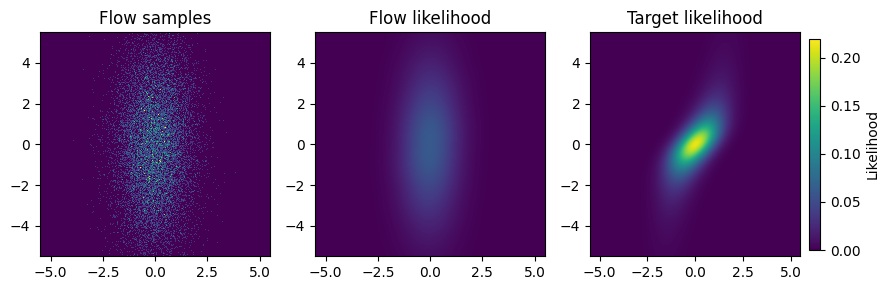

Training the flow:  25%|██▍       | 499/2000 [00:24<01:12, 20.84it/s, running loss=3.27]

Current training loss: 3.084


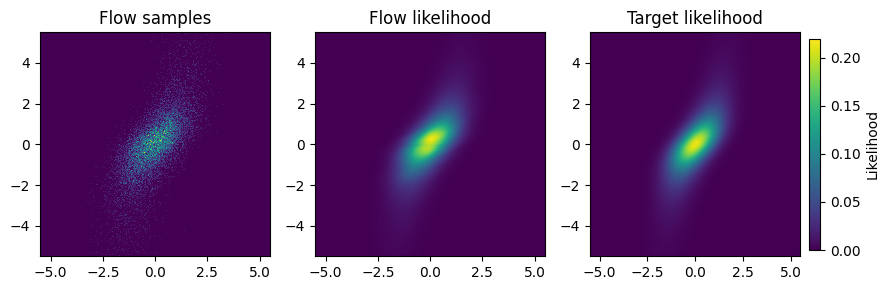

Training the flow:  50%|█████     | 1000/2000 [00:49<00:48, 20.71it/s, running loss=3.24]

Current training loss: 2.910


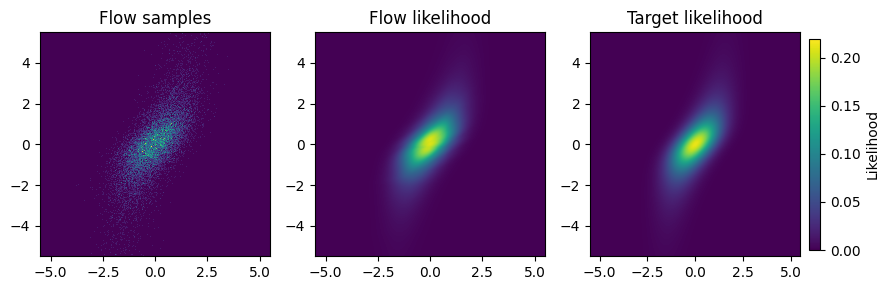

Training the flow:  75%|███████▌  | 1500/2000 [01:13<00:23, 21.54it/s, running loss=3.09]

Current training loss: 5.945


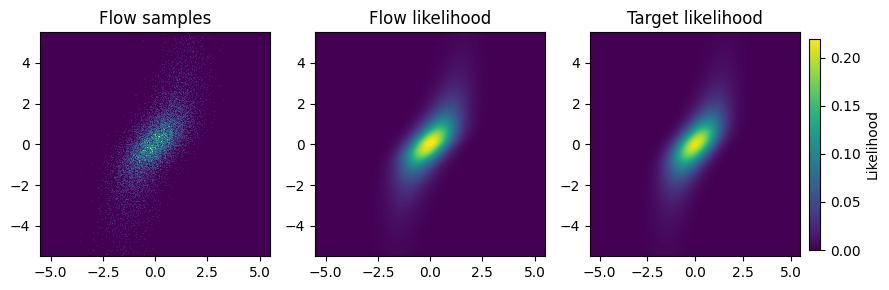

Training the flow: 100%|██████████| 2000/2000 [01:37<00:00, 20.41it/s, running loss=3.05]


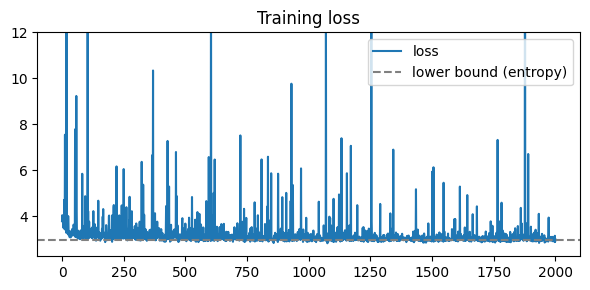

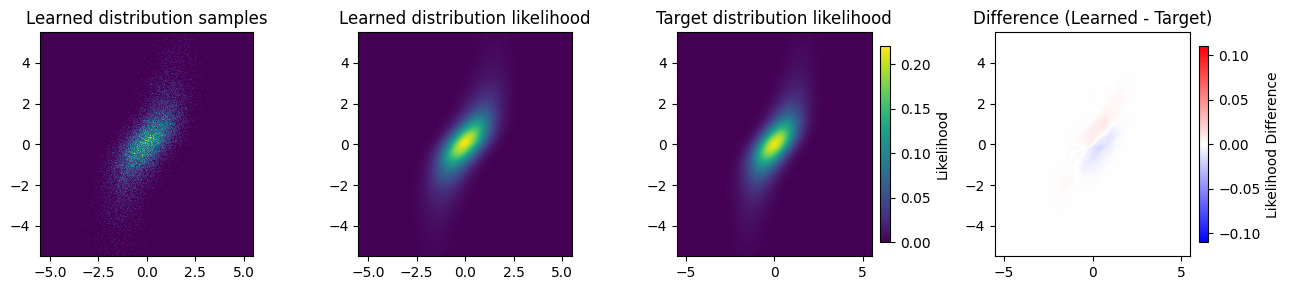

In [11]:
# Train model
train(nfm_baseline, target, 2000, show_every=500, model_name = "nfm_baseline")

In [12]:
# eval
outputs = eval_results(nfm_baseline, target)

# add other stuff, if we want
outputs["params"] = num_params_baseline

# append to results
results["nfm_baseline"] = outputs

Model does not have method 'get_average_nll', using the generic one for norm flows...
Average NLL (per dim!): 1.516
bin (-0.100, 0.100) for dim 0:


100%|██████████| 8/8 [00:02<00:00,  3.02it/s]


bin (-0.100, 0.100) for dim 1:


100%|██████████| 8/8 [00:02<00:00,  3.06it/s]


Average num true samps, num flow samps in bin (dim 0): 2552 ± 43 vs 2557 ± 25
Average num true samps, num flow samps in bin (dim 1): 2229 ±37 vs 2217 ± 45
Sliced Wasserstein distance: 0.065
1D Wasserstein distance mean over light tail dims: 0.019
1D Wasserstein distance mean over heavy tail dims: 0.099


### TTF models

In [13]:
# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

# Standard TTF
ttf_layer = ModifiedTailAffineMarginalTransform(
    features = 2,
    pos_tail_init = pos_tail_init.detach().clone(),
    neg_tail_init = neg_tail_init.detach().clone(),
    shift_init = shift_init.detach().clone(),
    scale_init = scale_init.detach().clone(),
    hd_only = hd_only,
    mod = "std",
    fix_params = False,
)

# Construct flow model
nfm_ttf = nf.NormalizingFlow(q0=q0, flows=build_flows() + [ttf_layer])
nfm_ttf = nfm_ttf.to(device)

# Print number of parameters
num_params_ttf = sum(p.numel() for p in nfm_ttf.parameters() if p.requires_grad)
print(f"Num params nfm_ttf: ", num_params_ttf)

Standard TTF: No breaking points needed, thus fixed.
Fixed breakpoint params.
Num params nfm_ttf:  112616


ActNorm layers calibrated..


Training the flow:   0%|          | 0/2000 [00:00<?, ?it/s, running loss=3.43]

Current training loss: 3.350


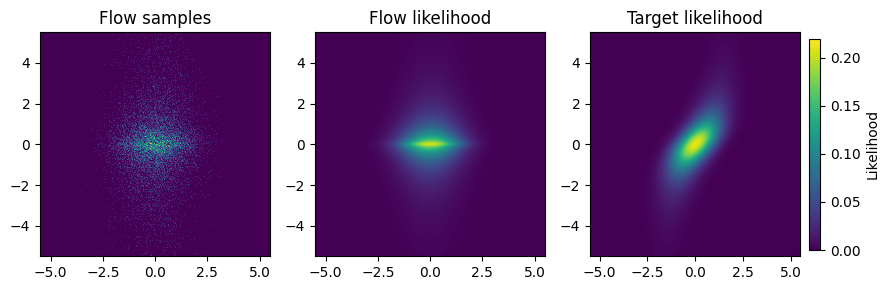

Training the flow:   0%|          | 3/2000 [00:00<05:27,  6.10it/s, running loss=3.41]

pos_tail:  tensor([0.0000, 0.5000], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0000, 0.5000], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([-1.0000e-04,  1.0000e-04], device='cuda:3', requires_grad=True)
scale:  tensor([1.0009, 1.0009], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  25%|██▌       | 500/2000 [00:26<01:14, 20.02it/s, running loss=2.97]

Current training loss: 2.958


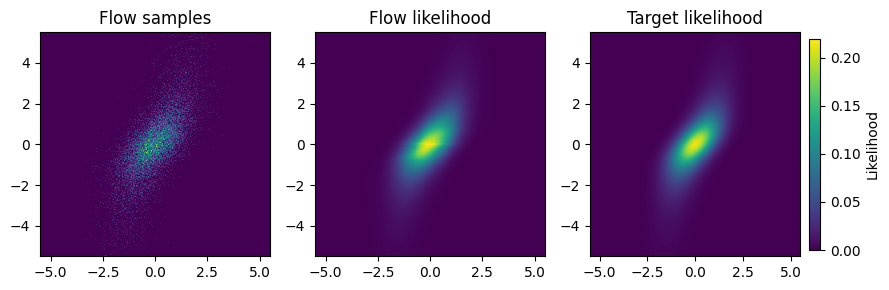

Training the flow:  25%|██▌       | 503/2000 [00:26<02:15, 11.07it/s, running loss=2.97]

pos_tail:  tensor([0.0000, 0.4810], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0000, 0.4811], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([-0.0023,  0.0004], device='cuda:3', requires_grad=True)
scale:  tensor([0.9997, 0.9732], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  50%|████▉     | 999/2000 [00:52<00:51, 19.32it/s, running loss=2.96]

Current training loss: 2.947


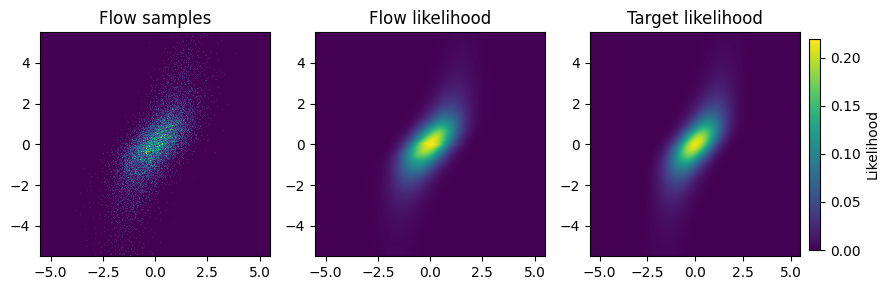

Training the flow:  50%|█████     | 1003/2000 [00:53<01:50,  9.03it/s, running loss=2.96]

pos_tail:  tensor([0.0000, 0.4639], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0000, 0.4640], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([-0.0018,  0.0008], device='cuda:3', requires_grad=True)
scale:  tensor([1.0003, 0.9518], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  75%|███████▍  | 1499/2000 [01:19<00:26, 18.99it/s, running loss=2.97]

Current training loss: 2.935


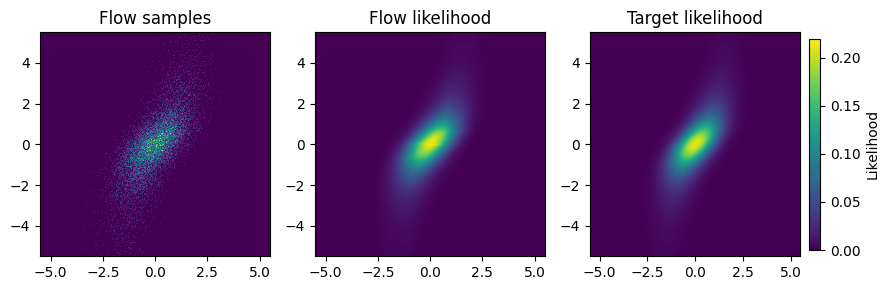

Training the flow:  75%|███████▌  | 1503/2000 [01:19<00:46, 10.64it/s, running loss=2.98]

pos_tail:  tensor([0.0000, 0.4483], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0000, 0.4479], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([-0.0013, -0.0011], device='cuda:3', requires_grad=True)
scale:  tensor([0.9997, 0.9381], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow: 100%|██████████| 2000/2000 [01:46<00:00, 18.86it/s, running loss=2.97]


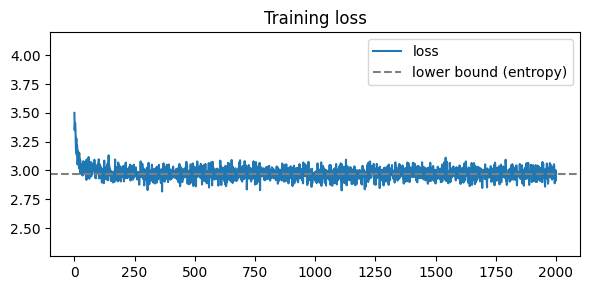

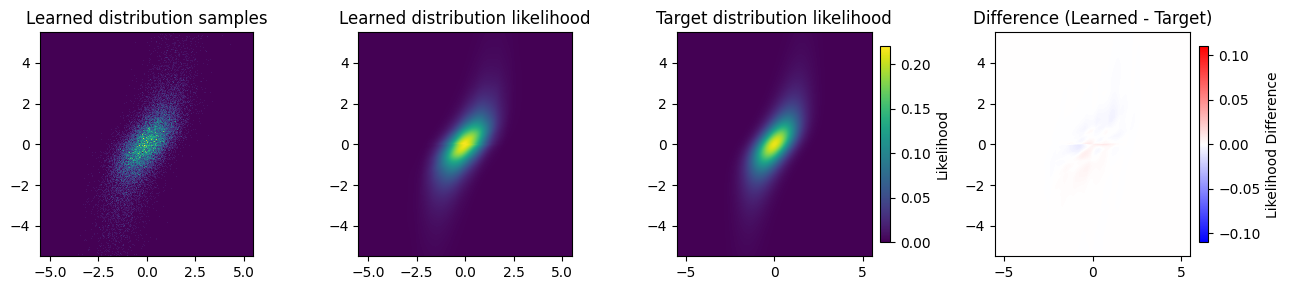

pos_tail:  tensor([0.0000, 0.4336], device='cuda:3', grad_fn=<SoftplusBackward0>)
neg_tail:  tensor([0.0000, 0.4331], device='cuda:3', grad_fn=<SoftplusBackward0>)
shift:  Parameter containing:
tensor([-0.0012, -0.0011], device='cuda:3', requires_grad=True)
scale:  tensor([0.9990, 0.9318], device='cuda:3', grad_fn=<AddBackward0>)


In [14]:
# train model
train(nfm_ttf, target, 2000, show_every=500, model_name = "nfm_ttf")

In [15]:
# eval
outputs = eval_results(nfm_ttf, target)

# add other stuff, if we want
outputs["params"] = num_params_ttf

# append to results
results["nfm_ttf"] = outputs

Model does not have method 'get_average_nll', using the generic one for norm flows...
Average NLL (per dim!): 1.486
bin (-0.101, 0.099) for dim 0:


100%|██████████| 8/8 [00:02<00:00,  2.87it/s]


bin (-0.101, 0.099) for dim 1:


100%|██████████| 8/8 [00:02<00:00,  3.03it/s]


Average num true samps, num flow samps in bin (dim 0): 2601 ± 46 vs 2586 ± 30
Average num true samps, num flow samps in bin (dim 1): 2291 ±51 vs 2303 ± 39
Sliced Wasserstein distance: 0.051
1D Wasserstein distance mean over light tail dims: 0.018
1D Wasserstein distance mean over heavy tail dims: 0.076


### Modified TTF versions

In [18]:
# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

# TTF layer with modifications
ttf_mod_layer = ModifiedTailAffineMarginalTransform(
    features = 2,
    pos_tail_init = pos_tail_init.detach().clone(),
    neg_tail_init = neg_tail_init.detach().clone(),
    shift_init = shift_init.detach().clone(),
    scale_init = scale_init.detach().clone(),
    hd_only = hd_only,
    mod = "qua",
    fix_params = False,
)

# Construct flow model
nfm_ttf_mod = nf.NormalizingFlow(q0=q0, flows=build_flows() + [ttf_mod_layer])
nfm_ttf_mod = nfm_ttf_mod.to(device)

# Print number of parameters
num_params_ttf_mod = sum(p.numel() for p in nfm_ttf_mod.parameters() if p.requires_grad)
print(f"Num params nfm_ttf_mod: ", num_params_ttf_mod)

Quadratic-slope TTF modification currently only works with fixed tailparams and breaking points (TTFfix). Also, breaking points are computed automatically (overwriting user inputs for these parameters) to ensure invertibility.
Compute a_neg to ensure invertibility...
Computed a_neg:  tensor([-0.6279, -0.9465])
Compute a_pos to ensure invertibility...
Computed a_pos:  tensor([0.6279, 0.9465])
Quadratic-derivative TTF: Fix tailparams and breaking points.
Fixed tailparams.
Fixed breakpoint params.
Num params nfm_ttf_mod:  112612


ActNorm layers calibrated..


Training the flow:   0%|          | 0/2000 [00:00<?, ?it/s, running loss=3.39]

Current training loss: 3.354


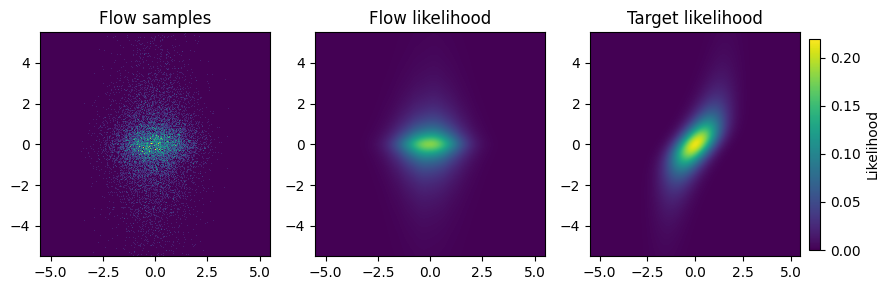

Training the flow:   0%|          | 3/2000 [00:00<06:58,  4.78it/s, running loss=3.37]

pos_tail:  tensor([0.0000, 0.5000], device='cuda:3')
neg_tail:  tensor([0.0000, 0.5000], device='cuda:3')
shift:  Parameter containing:
tensor([1.0000e-04, 1.0000e-04], device='cuda:3', requires_grad=True)
scale:  tensor([1.0009, 1.0009], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  25%|██▍       | 499/2000 [00:27<01:23, 18.03it/s, running loss=2.98]

Current training loss: 2.948


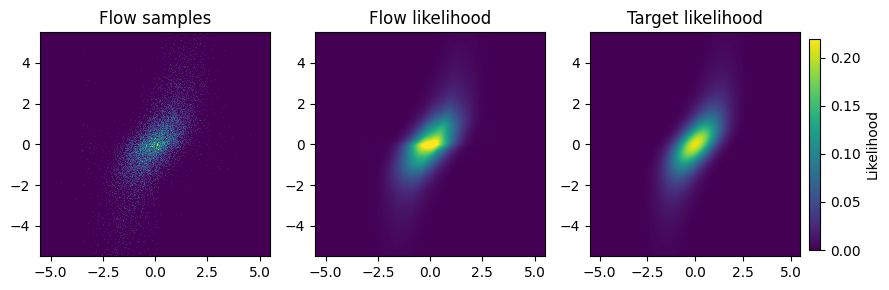

Training the flow:  25%|██▌       | 503/2000 [00:28<02:30,  9.92it/s, running loss=2.98]

pos_tail:  tensor([0.0000, 0.5000], device='cuda:3')
neg_tail:  tensor([0.0000, 0.5000], device='cuda:3')
shift:  Parameter containing:
tensor([0.0021, 0.0009], device='cuda:3', requires_grad=True)
scale:  tensor([1.0108, 0.9639], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  50%|████▉     | 999/2000 [00:56<00:53, 18.56it/s, running loss=2.97]

Current training loss: 3.039


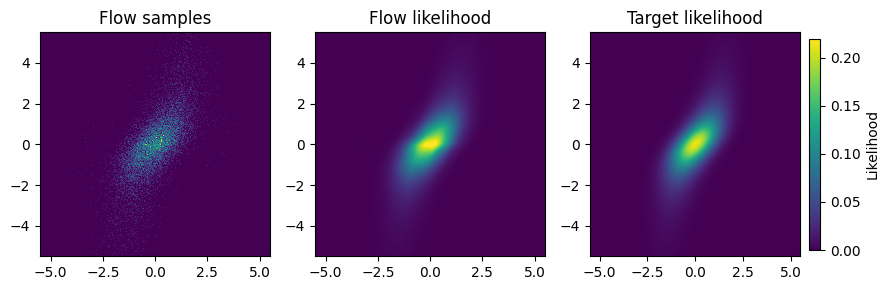

Training the flow:  50%|█████     | 1003/2000 [00:56<01:36, 10.38it/s, running loss=2.97]

pos_tail:  tensor([0.0000, 0.5000], device='cuda:3')
neg_tail:  tensor([0.0000, 0.5000], device='cuda:3')
shift:  Parameter containing:
tensor([0.0032, 0.0013], device='cuda:3', requires_grad=True)
scale:  tensor([1.0161, 0.9307], device='cuda:3', grad_fn=<AddBackward0>)


Training the flow:  75%|███████▌  | 1500/2000 [01:11<00:23, 21.04it/s, running loss=nan] 


AssertionError: 

In [19]:
# Train model
train(nfm_ttf_mod, target, 2000, show_every=500, model_name = "nfm_ttf_mod")

In [ ]:
# eval
outputs = eval_results(nfm_ttf_mod, target)

# add other stuff, if we want
outputs["params"] = num_params_ttf_mod  

# append to results
results["nfm_ttf_mod"] = outputs

### NSF + Logtransform

In [ ]:
# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

# TTF layer with modifications
soft_log_layer = SoftLogMarginalTransform(
        features = 2,
        pos_tail_init = pos_tail_init.detach().clone(),
        neg_tail_init = neg_tail_init.detach().clone(),
        shift_init = shift_init.detach().clone(),
        scale_init = scale_init.detach().clone(),
        hd_only = hd_only,
        mod = "std", # "std" or "qua"
        a_pos_init = None,
        a_neg_init = None,
        fix_params = True,
    )

# Construct flow model
nfm_ttf_softlog = nf.NormalizingFlow(q0=q0, flows=build_flows() + [soft_log_layer])
nfm_ttf_softlog = nfm_ttf_softlog.to(device)

# Print number of parameters
num_params_ttf_softlog = sum(p.numel() for p in nfm_ttf_softlog.parameters() if p.requires_grad)
print(f"Num params nfm_ttf_softlog: ", num_params_ttf_softlog)

In [ ]:
# Train model
train(nfm_ttf_softlog, target, 2000, show_every=500, model_name = "nfm_ttf_softlog")

In [ ]:
# eval
outputs = eval_results(nfm_ttf_softlog, target)

# add other stuff, if we want
outputs["params"] = num_params_ttf_softlog  

# append to results
results["nfm_ttf_softlog"] = outputs

### NSF + Arcsinh Transform

In [ ]:
# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

# TTF layer with modifications
from tailnflows.models.extreme_transformations import ArcsinhMarginalTransform

arcsinh_layer = ArcsinhMarginalTransform(
        features = 2,
        pos_tail_init = pos_tail_init.detach().clone(),
        neg_tail_init = neg_tail_init.detach().clone(),
        shift_init = shift_init.detach().clone(),
        scale_init = scale_init.detach().clone(),
        hd_only = hd_only,
        mod = "std", # "std" or "qua"
        a_pos_init = None, #torch.tensor([2.0,2.0]), # torch.tensor([2.0,2.0]), #None,
        a_neg_init = None, # torch.tensor([-2.0,-2.0]), # torch.tensor([2.0,2.0]), #None,
        fix_params = False,
    )


# Construct flow model
nfm_ttf_arcsinh = nf.NormalizingFlow(q0=q0, flows=build_flows() + [arcsinh_layer])
nfm_ttf_arcsinh = nfm_ttf_arcsinh.to(device)

# Print number of parameters
num_params_ttf_arcsinh = sum(p.numel() for p in nfm_ttf_arcsinh.parameters() if p.requires_grad)
print(f"Num params nfm_ttf_arcsinh: ", num_params_ttf_arcsinh)

In [ ]:
# Train model
train(nfm_ttf_arcsinh, target, 2000, show_every=500, model_name = "nfm_ttf_arcsinh")

In [ ]:
# eval
outputs = eval_results(nfm_ttf_arcsinh, target)

# add other stuff, if we want
outputs["params"] = num_params_ttf_arcsinh  

# append to results
results["nfm_ttf_arcsinh"] = outputs

## Compare Flow Matching Models

### Define FM vector fields:

In [ ]:
import torch.nn as nn
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver
from flow_matching.utils import ModelWrapper

# Sinusoidal time embedding
class TimeEmbedding(nn.Module):
    def __init__(self, time_emb_dim: int):
        super().__init__()
        self.time_emb_dim = time_emb_dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        """
        Embed 1-d time into {time_emb_dim}-dimensional space.

        Args:
            t (torch.Tensor): Shape [batch] or [batch, 1].

        Returns:
            temb (torch.Tensor): Shape [batch, time_emb_dim].
        """
        if t.dim() == 1:
            t = t[:, None]

        half_dim = self.time_emb_dim // 2
        freqs = torch.exp(
            torch.linspace(
                0,
                torch.log(torch.tensor(1000.0, device=t.device)),
                half_dim,
                device=t.device,
            )
        )
        args = t * freqs[None, :] * 2.0 * torch.pi
        temb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.time_emb_dim % 2 == 1:
            temb = torch.cat([temb, t], dim=-1)

        return temb


# Residual layer with smooth SiLU activation
class ResidualBlock(nn.Module):
    def __init__(self, dim: int, hidden_dim: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Shape [batch, dim]

        Returns:
            torch.Tensor: Shape [batch, dim]
        """
        return x + self.net(x)


# Time-dependent vector field for Flow Matching models
class FMVectorField(nn.Module):
    def __init__(
        self,
        x_dim: int = 2,
        hidden_dim: int = 64,
        num_blocks: int = 4,
        time_emb_dim: int = 16,
    ):
        super().__init__()

        self.x_dim = x_dim
        self.time_embedding = TimeEmbedding(time_emb_dim)

        input_dim = x_dim + time_emb_dim

        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.SiLU(),
        )

        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, hidden_dim)
            for _ in range(num_blocks)
        ])

        self.output_layer = nn.Linear(hidden_dim, x_dim)

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x (torch.Tensor): Shape [batch, x_dim].
            t (torch.Tensor): Shape [batch] or [batch, 1].

        Returns:
            v (torch.Tensor): Velocity vector field at point x and time t (shape [batch, x_dim]).
        """

        # Ensure t has the same batch size as x
        if t.dim() == 0:  # scalar
            t = t.expand(x.shape[0])
        elif t.dim() == 1 and t.shape[0] == 1:
            t = t.expand(x.shape[0])
        
        temb = self.time_embedding(t)
        h = torch.cat([x, temb], dim=-1)

        h = self.input_layer(h)

        for block in self.blocks:
            h = block(h)

        v = self.output_layer(h)
        return v

### Define FM loss:

In [ ]:
# Conditional FM loss for linear Gaussian prob. paths
mse_loss = nn.MSELoss() #reduction="none") # use non for weighted loss..
def cfm_loss(vf: FMVectorField, x1: torch.Tensor, q0: nf.distributions.BaseDistribution) -> torch.Tensor:
    """
    Conditional Flow Matching loss for linear (OT) Gaussian Probability Path.

    Args:
        vf (FMVectorField): FM vector field.
        x1 (torch.Tensor): Data batch (shape: [batch_size, features]).
        q0 (nf.distributions.BaseDistribution): Base distribution of the FM model (Usually N(0,I)).

    Returns:
        loss (torch.Tensor): loss on data batch (shape: []).
    """
    batch_size = x1.shape[0]
    device = x1.device

    # Instantiate OT probability path
    path = AffineProbPath(scheduler=CondOTScheduler())

    # sample from base distribution
    x0, _ = q0.forward(batch_size)
    x0 = x0.to(dtype=DEFAULT_DTYPE, device=device)

    # sample time uniformly
    t = torch.rand(batch_size, device=device).to(device)

    # Sample probability path
    path_sample = path.sample(x0, x1, t)

    # Conditional FM l2 loss
    loss = mse_loss(vf(path_sample.x_t.to(device), path_sample.t.to(device)), path_sample.dx_t.to(device))

    # weights = torch.log(1 + torch.norm(x1, dim=1, p = 1.0))
    # print("weights", weights.shape)
    # print("predicted vf", vf(path_sample.x_t.to(device), path_sample.t.to(device)).shape)
    # print("true vf", path_sample.dx_t.to(device).shape)
    
    # loss_per_sample = loss.mean(dim=1)
    # # print(loss_per_sample.shape)
    # loss = loss_per_sample * weights
    # loss = (loss_per_sample * weights).sum() / weights.sum()
    return loss

### Add final TTF layer:

In [ ]:
class IdentityTransform(Transform):
    """ Identity function in feature space. """

    def __init__(self, features: int):
        super().__init__()
        self.features = features

    def forward(self, z: torch.Tensor, context=None) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            z (torch.Tensor): Shape [batch, features].

        Returns:
            z, lad (tuple[torch.Tensor, torch.Tensor]): lad (=0) is summed over dimension: Shape [batch].
        """
        lad = torch.zeros_like(z)
        return z, lad.sum(dim=-1)

    def inverse(self, x: torch.Tensor, context=None) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            x (torch.Tensor): Shape [batch, features].

        Returns:
            x, lad (tuple[torch.Tensor, torch.Tensor]): lad (=0) is summed over dimension: Shape [batch].
        """
        lad = torch.zeros_like(x)
        return x, lad.sum(dim=-1)
    

class FM_TTF_model(torch.nn.Module):
    """ Implementation of a Flow Matching model together with an optional final tail (TTF) transformation. """

    def __init__(self, device: torch.device, vf: FMVectorField, q0: nf.distributions.BaseDistribution, tail_trafo: Optional[Transform] = None):
        """
        Build combined model consisting of a FM velocity field and a final tail transformation.

        Args:
            device (torch.device): Device.
            vf (FMVectorField): Flow Matching velocity field.
            q0 (nf.distributions.BaseDistribution): Base distribution of the FM model.
            tail_trafo (Transform, optional): Final tail transformation. If given None, the identity transformation is used. Defaults to None.
        """
        super().__init__()
        self.features = vf.x_dim
        self.device = device
        self.vf = vf.to(device)
        self.q0 = q0.to(device)
        if tail_trafo is None:
            tail_trafo = IdentityTransform(features=vf.x_dim) # Default: Identity Transformation
        self.tail_trafo = tail_trafo.to(device)

        assert self.features == self.tail_trafo.features, f"Mismatch in dimension of vf ({self.features}) and dimension of tail_trafo ({self.tail_trafo.features})."

        # Fix TTF params
        if isinstance(self.tail_trafo, (TailAffineMarginalTransform, ModifiedTailAffineMarginalTransform)):
            print("Currently, learning the TTF params is not possible for FM-TTF models. Therefore, TTF params will be fixed.")
            if isinstance(self.tail_trafo, ModifiedTailAffineMarginalTransform):
                self.tail_trafo.fix_all()
            elif isinstance(self.tail_trafo, TailAffineMarginalTransform):
                self.tail_trafo.fix_tails()
                print("Fixed tailparams.")
                self.tail_trafo.shift.requires_grad = False
                print("Fixed location params.")
                self.tail_trafo._unc_scale.requires_grad = False
                print("Fixed scale params.")

    @torch.no_grad()
    def sample(self, num_samps: int, method: str = "dopri5", step_size: Optional[float] = None, **ode_extras) -> torch.Tensor:
        """ Sample from model.

        Args:
            num_samps (int): Number of samples.
            method (str, optional): Method for ODE solver. Defaults to "dopri5".
            step_size (float, optional): Stepsize for ODE solver. Must be None for adaptive solvers. Defaults to None.
            **ode_extras: Additional config for ODE solver.

        Returns:
            x1 (torch.Tensor): Samples (shape: [num_samps, self.features])
        """
        # Sample from base distribution
        x0 = self.q0.sample(num_samps)
        if isinstance(x0, tuple):
            x0 = x0[0] # take only samples, not log_prob
        x0 = x0.to(self.device)

        # Solve forward ODE
        solver = ODESolver(ModelWrapper(self.vf))
        y = solver.sample(x0, step_size=step_size, method=method, **ode_extras)

        # Apply tail transformation
        x1, _ = self.tail_trafo.forward(y)

        return x1

    @torch.no_grad()
    def log_prob(self, x1: torch.Tensor, method: str = "dopri5", exact_divergence: bool = False, step_size: Optional[float] = None, **ode_extras) -> torch.Tensor:
        """ Compute log_prob on data batch x1.

        Args:
            x1 (torch.Tensor): Data batch (shape: [batch_size, self.features])
            method (str, optional): Method for ODE solver. Defaults to "dopri5".
            exact_divergence (bool, optional): Whether to use exact diversion or Hutchinson estimator in ODE solver. Defaults to False.
            step_size (float, optional): Stepsize for ODE solver. Must be None for adaptive solvers. Defaults to None.
            **ode_extras: Additional config for ODE solver.

        Returns:
            log_p (torch.Tensor): log prob values for all data points (summed over feature dimension) (shape: [batch]).
        """
        x1 = x1.to(self.device)

        print(f"Computing likelihood on tensor of shape {x1.shape}...")

        # Apply inverse tail transformation
        y, lad = self.tail_trafo.inverse(x1)
        y = y.to(self.device)
        lad = lad.to(self.device)

        # Solve reverse-time ODE
        solver = ODESolver(ModelWrapper(self.vf))
        _ , log_p = solver.compute_likelihood(y, self.q0.log_prob, step_size=step_size, method=method, exact_divergence=exact_divergence, **ode_extras)
        log_p = log_p.to(self.device)

        # Change of variables formula
        log_p = log_p + lad

        return log_p

    @torch.no_grad()
    def get_average_nll(self, target: Target, num_samps: int = 16000, method: str = 'dopri5', batch_size: int = 64000, exact_divergence: bool = True, step_size: Optional[float] = None, **ode_extras) -> float:
        """ Compute average NLL per target sample and dimension. Computation is split in batches to reduce peak usage.

        Args:
            target (Target): Target distribution.
            num_samps (int, optional): Number of independent samples drawn from target distribution to compute average NLL on. Defaults to 16000.
            method (str, optional): Method for ODE sovler. Defaults to 'dopri5'.
            batch_size (int, optional): Size of batches on which likelihood is computed simultaneously. Defaults to 4096.
            exact_divergence (bool, optional): Whether to use exact divergence or Hutchinson estimator in ODE solver. Defaults to True.
            step_size (float, optional): Stepsize for ODE solver. Must be None for adaptive solvers. Defaults to None.
            **ode_extras: Additional config for ODE solver.

        Returns:
            nll (float): Average NLL per sample and dimension.
        """
        # Sample independent target data points
        x1 = target.sample(num_samps).to(dtype=DEFAULT_DTYPE, device=self.device)

        # Compute log_p in batches
        total_log_p = 0.0

        for start in tqdm(range(0, num_samps, batch_size)):

            # Compute batch log_p
            end = min(start + batch_size, num_samps)
            batch = x1[start:end]
            log_p = self.log_prob(batch, method=method, exact_divergence=exact_divergence, step_size=step_size, **ode_extras)

            # Add to total log_p and delete batch results to free memory
            total_log_p += log_p.sum().item()
            del batch, log_p
            if device.type == 'cuda':
                torch.cuda.empty_cache()

        # Average total NLL over samples and dimension
        nll = -total_log_p / (num_samps * self.features)

        return nll

    def train(self, target: Target, num_steps: int = 1000, batch_size: int = 1024, show_every: Optional[int] = None, lr: float = 1e-4, weight_decay: float = 1e-5, model_name: Optional[str] = None):
        """ Train the model on target distribution. Trains only the FM vector field, not the final transformation.

        Args:
            target (Target): Target distribution to train the model on.
            num_steps (int, optional): Number of training steps. Defaults to 1000.
            batch_size (int, optional): Defaults to 512.
            show_every (int, optional): Period for visualizing intermediate results (only for 2dim). If None, no intermediate results are computed. Defaults to None.
            lr (float, optional): Learning rate for optimizer. Defaults to 1e-3.
            weight_decay (float, optional): Weight decay for optimizer. Defaults to 1e-5.
            model_name (str, optional): Name of the model for saving intermediate results. Defaults to None.
        """
        target = target.to(self.device)

        # Prepare loss history
        loss_hist = np.array([])

        # Get training samples for initial loss
        x = target.sample(batch_size).to(dtype=DEFAULT_DTYPE, device=self.device)
        # Apply inverse tail transform
        y, _ = self.tail_trafo.inverse(x)
        # Compute and log initial loss
        loss = cfm_loss(self.vf, y.to(self.device), self.q0)
        loss_hist = np.append(loss_hist, loss.to('cpu').item())

        # Training loop
        optimizer = torch.optim.AdamW(self.vf.parameters(), lr=lr, weight_decay=weight_decay)

        pbar = tqdm(range(num_steps), desc="Training steps")
        for step in pbar:
            optimizer.zero_grad()

            # Get training batch
            x = target.sample(batch_size).to(dtype=DEFAULT_DTYPE, device=self.device)
            # Apply inverse tail transform
            y, _ = self.tail_trafo.inverse(x)

            # Compute loss
            loss = cfm_loss(self.vf, y, self.q0)

            # Do backprop and optimizer step
            if ~(torch.isnan(loss) | torch.isinf(loss)):
                loss.backward()

                # clip grad norm to stabilize training... 
                torch.nn.utils.clip_grad_norm_(
                    self.vf.parameters(),
                    max_norm=5.0,
                )
                optimizer.step()

            # log loss in progress bar
            loss_hist = np.append(loss_hist, loss.to('cpu').item())
            pbar.set_postfix({"running loss": loss_hist[-100:].mean()})

            # Compute and show intermediate results
            if show_every is not None and self.features == 2:
                if step % show_every == 0:
                    # Sample from model
                    samples = self.sample(16000)
                    samples = samples.detach().cpu().numpy()
                    # Compute likelihood on grid
                    log_prob = self.log_prob(grid)
                    prob = torch.exp(log_prob).reshape(grid_size, grid_size)
                    prob[torch.isnan(prob)] = 0
                    prob = prob.detach().cpu().numpy()

                    # Visualize flow distribution
                    fig, axs = plt.subplots(1, 3, figsize=(9, 3))
                    axs[0].hist2d(samples[:, 0], samples[:, 1], bins=bins, range=range_hist2d, density=True)
                    axs[0].set_title("Flow samples")
                    axs[1].imshow(prob, extent=extent_imshow, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
                    axs[1].set_title("Flow likelihood")
                    # also add the target distribution for comparison
                    axs[2].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
                    axs[2].set_title('Target distribution likelihood')
                    # add colorbar to right of axs[2]
                    cbar = fig.colorbar(axs[2].images[0], ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)
                    cbar.set_label('Likelihood')
                    print(f"Current training loss: {loss.to('cpu').data.numpy():.3f}")
                    plt.tight_layout()
                    plt.show()

        # Plot loss history
        fig, ax = plt.subplots(1, 1, figsize=(6, 3))
        ax.plot(loss_hist, label='loss')
        ax.set_ylim(min(loss_hist)*0.8, max(np.clip(loss_hist, None, 10.0)*1.2))
        ax.set_title('Training loss')
        # add lower bound on loss based on entropy of target distribution
        ax.axhline(entropy_estimate, color='gray', linestyle='--', label='lower bound (entropy)')
        plt.tight_layout()
        plt.show()

        # Plot final distribution
        if self.features == 2:
            samples = self.sample(32000)
            samples = samples.detach().cpu().numpy()
            log_prob = self.log_prob(grid, exact_divergence=True)
            prob = torch.exp(log_prob).reshape(grid_size, grid_size)
            prob[torch.isnan(prob)] = 0
            prob = prob.detach().cpu().numpy()

            fig, axs = plt.subplots(1, 4, figsize=(13, 3))
            axs[0].hist2d(samples[:, 0], samples[:, 1], bins=bins, range=range_hist2d, density=True)
            axs[0].set_title("Flow samples")
            axs[1].imshow(prob, extent=extent_imshow, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
            axs[1].set_title("Flow likelihood")
            axs[2].imshow(target_likelihood, extent=extent_imshow, aspect='auto', origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
            axs[2].set_title("Target distribution likelihood")  
            # add colorbar for ax[2]
            cbar = fig.colorbar(axs[2].images[0], ax=axs[2], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('Likelihood')

        
            # also add difference between learned and target likelihoods in red
            diff = prob - target_likelihood
            axs[3].imshow(diff, extent=extent_imshow, aspect='auto', origin='lower', cmap='bwr', vmin=-vmax/2.0, vmax=vmax/2.0)
            axs[3].set_title('Difference (Learned - Target)')
            cbar = fig.colorbar(axs[3].images[0], ax=axs[3], orientation='vertical', fraction=0.046, pad=0.04)
            cbar.set_label('Likelihood Difference')

            plt.tight_layout()
            if model_name is not None:
                plt.savefig(results_dir + model_name + '_final_distribution.png')
            plt.show()

    @torch.no_grad()
    def bin_count(self, target: Target, dim: int, bin: Optional[tuple[float, float]] = None, num_samps: int = 32000, repeats: int = 8,
                  method: str = "dopri5", step_size: Optional[float] = None, **ode_extras) -> tuple[tuple[float, float], tuple[float, float]]:
        """
        Compute average number of true samples and flow samples in bin for specified dimension.

        Args:
            target (Target): Target distribution.
            dim (int): Dimension in which to count.
            bin (tuple[float, float], optional): Interval (bin) in which to count samples. If given None, defaults to small interval around shift of final tail transform. Defaults to None.
            num_samps (int, optional): Number of independent samples drawn from both target and flow distribution. Defaults to 16000.
            repeats (int, optional): Number of repeats to average results over. Defaults to 8.
            method (str, optional): Method for ODE solver. Defaults to "dopri5".
            step_size (float, optional): Stepsize for ODE solver. Must be None for adaptive solvers. Defaults to None.
            **ode_extras: Additional config for ODE solver.

        Returns:
            (avg_num_true_in_bin, std_num_true_in_bin), (avg_num_flow_in_bin, std_num_flow_in_bin) (tuple[tuple[float, float], tuple[float, float]]): Results for target and flow samples (mean, std).
        """
        assert dim >= 0 and dim <= self.features - 1, f"Invalid dimension {dim} for model with {self.features} features."

        if bin is None:
            # Set default bin around shift of final transformation
            mu = 0.0
            if hasattr(self.tail_trafo, 'shift'):
                mu = self.tail_trafo.shift[dim].to(DEFAULT_DTYPE).item() # type: ignore 
            bin = (mu - 0.1, mu + 0.1)

        print(f"bin ({bin[0]:.3f}, {bin[1]:.3f}) for dim {dim}:")

        # Compute average number of samples in bin for target and flow samples
        results_true = []
        results_flow = []
        for i in tqdm(range(repeats)):
            true_samps = target.sample(num_samps)
            flow_samps = self.sample(num_samps, method=method, step_size=step_size, **ode_extras)
            true_samps = true_samps[:, dim]
            flow_samps = flow_samps[:, dim]
            num_true_in_bin = ((bin[0] < true_samps) & (true_samps < bin[1])).sum().item()
            num_flow_in_bin = ((bin[0] < flow_samps) & (flow_samps < bin[1])).sum().item()
            results_true.append(num_true_in_bin)
            results_flow.append(num_flow_in_bin)

        avg_num_true_in_bin = float(np.mean(results_true))
        std_num_true_in_bin = float(np.std(results_true))
        avg_num_flow_in_bin = float(np.mean(results_flow))
        std_num_flow_in_bin = float(np.std(results_flow))

        return (avg_num_true_in_bin, std_num_true_in_bin), (avg_num_flow_in_bin, std_num_flow_in_bin)

### FM baseline (without tail transform):

In [ ]:
fm_baseline_model = FM_TTF_model(
    device,
    FMVectorField(
        x_dim = 2,
        hidden_dim = 128,
        num_blocks = 3,
        time_emb_dim = 32,
    ),
    q0,
)

# Print number of parameters
num_params_fm_baseline = sum(p.numel() for p in fm_baseline_model.parameters() if p.requires_grad)
print(f"Num params fm_baseline: ", num_params_fm_baseline)

In [ ]:
fm_baseline_model.train(target, 2000, show_every=2000, model_name="fm_baseline")

In [ ]:
# eval
outputs = eval_results(fm_baseline_model, target)

# add other stuff, if we want
outputs["params"] = num_params_fm_baseline

# append to results
results["flow_matching_baseline"] = outputs

<!-- ### FM + TTF model -->

### FM + TTF model

In [ ]:
# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

fm_ttf_model = FM_TTF_model(
    device,
    FMVectorField(
        x_dim = 2,
        hidden_dim = 128,
        num_blocks = 3,
        time_emb_dim = 32,
    ),
    q0,
    ModifiedTailAffineMarginalTransform(
        features = 2,
        pos_tail_init = pos_tail_init.detach().clone(),
        neg_tail_init = neg_tail_init.detach().clone(),
        shift_init = shift_init.detach().clone(),
        scale_init = scale_init.detach().clone(),
        hd_only = hd_only,
        mod = "std", # "std" or "qua"
        a_pos_init = None,
        a_neg_init = None,
        fix_params = True,
    ),
)

# Print number of parameters
num_params_fm_ttf = sum(p.numel() for p in fm_ttf_model.parameters() if p.requires_grad)
print(f"Num params fm_ttf: ", num_params_fm_ttf)

In [ ]:
fm_ttf_model.train(target, 2000, show_every=2000, model_name="fm_ttf")

In [ ]:
# eval
outputs = eval_results(fm_ttf_model, target)

# add other stuff, if we want
outputs["params"] = num_params_fm_ttf

# append to results
results["flow_matching_ttf"] = outputs

### FM + TTF model (Quadratic)

In [ ]:
# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

fm_ttf_model_qua = FM_TTF_model(
    device,
    FMVectorField(
        x_dim = 2,
        hidden_dim = 128,
        num_blocks = 3,
        time_emb_dim = 32,
    ),
    q0,
    ModifiedTailAffineMarginalTransform(
        features = 2,
        pos_tail_init = pos_tail_init.detach().clone(),
        neg_tail_init = neg_tail_init.detach().clone(),
        shift_init = shift_init.detach().clone(),
        scale_init = scale_init.detach().clone(),
        hd_only = True,
        mod = "qua", # "std" or "qua"
        a_pos_init = None,
        a_neg_init = None,
        fix_params = True,
    ),
)

# Print number of parameters
num_params_fm_ttf_qua = sum(p.numel() for p in fm_ttf_model_qua.parameters() if p.requires_grad)
print(f"Num params fm_ttf (Quadratic): ", num_params_fm_ttf_qua)

In [ ]:
fm_ttf_model_qua.train(target, 2000, show_every=2000, model_name="fm_ttf_quadratic")

In [ ]:
# eval
outputs = eval_results(fm_ttf_model_qua, target)

# add other stuff, if we want
outputs["params"] = num_params_fm_ttf_qua

# append to results
results["flow_matching_ttf_quadratic"] = outputs

### FM + SoftLogMarginalTransform

In [ ]:
# from tailnflows.models.extreme_transformations import SoftLogMarginalTransform

# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

fm_ttflog_model = FM_TTF_model(
    device,
    FMVectorField(
        x_dim = 2,
        hidden_dim = 128,
        num_blocks = 3,
        time_emb_dim = 32,
    ),
    q0,
    SoftLogMarginalTransform(
        features = 2,
        pos_tail_init = pos_tail_init.detach().clone(),
        neg_tail_init = neg_tail_init.detach().clone(),
        shift_init = shift_init.detach().clone(),
        scale_init = scale_init.detach().clone(),
        hd_only = True,
        mod = "std", # "std" or "qua"
        a_pos_init = None,
        a_neg_init = None,
        fix_params = True,
    ),
)

# Print number of parameters
num_params_fm_ttflog = sum(p.numel() for p in fm_ttflog_model.parameters() if p.requires_grad)
print(f"Num params fm_ttflog: ", num_params_fm_ttflog)

In [ ]:
fm_ttflog_model.train(target, 2000, show_every=2000, model_name="fm_ttflog")

In [ ]:
# eval
outputs = eval_results(fm_ttflog_model, target)

# add other stuff, if we want
outputs["params"] = num_params_fm_ttflog

# append to results
results["flow_matching_log"] = outputs

### FM + ArcSinhMarginalTransform

What we want to have is a learnable "aggressiveness"? of the tail transform...
One potential solution would be to start with a arcsin transform, but make it explicitly learnable!

$$
a\cdot\operatorname{arcsinh}\left(\frac{x}{a}\right)
$$

In [ ]:
from tailnflows.models.extreme_transformations import ArcsinhMarginalTransform

# Tailparams
pos_tail_init = torch.tensor([0.0, 1/df])
neg_tail_init = torch.tensor([0.0, 1/df])

# Shift and scale
shift_init = torch.tensor([0.0, 0.0])
scale_init = torch.tensor([1.0, 1.0])

fm_arcsinh_model = FM_TTF_model(
    device,
    FMVectorField(
        x_dim = 2,
        hidden_dim = 128,
        num_blocks = 3,
        time_emb_dim = 32,
    ),
    q0,
    ArcsinhMarginalTransform(
        features = 2,
        pos_tail_init = pos_tail_init.detach().clone(),
        neg_tail_init = neg_tail_init.detach().clone(),
        shift_init = shift_init.detach().clone(),
        scale_init = scale_init.detach().clone(),
        hd_only = True,
        mod = "std", # "std" or "qua"
        a_pos_init = None, #torch.tensor([2.0,2.0]), # torch.tensor([2.0,2.0]), #None,
        a_neg_init = None, # torch.tensor([-2.0,-2.0]), # torch.tensor([2.0,2.0]), #None,
        fix_params = False,
    ),
)

# Print number of parameters
num_params_fm_arcsinh = sum(p.numel() for p in fm_arcsinh_model.parameters() if p.requires_grad)
print(f"Num params fm_arcsinh: ", num_params_fm_arcsinh)

In [ ]:
fm_arcsinh_model.train(target, 2000, show_every=2000, model_name="fm_arcsinh")

In [ ]:
# eval
outputs = eval_results(fm_arcsinh_model, target)

# add other stuff, if we want
outputs["params"] = num_params_fm_arcsinh

# append to results
results["flow_matching_arcsinh"] = outputs

# Save results

In [ ]:
import pandas as pd
list(results.keys())

In [ ]:
# to pandas data frame
results_df = pd.DataFrame.from_dict(results, orient="index")

# save to CSV file
current_time_stamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")
results_df.to_csv(results_dir + "results_" + current_time_stamp + ".csv")
print("Results saved to file!")

In [ ]:
# make df nice
results_df = pd.DataFrame(results).T

In [ ]:
# results_df, sort by nll
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="sliced_wp")
results_df